# t-SNE / UMAP — Backbone Feature Visualisation (3-way: ImageNet vs A1 vs A2)

**Purpose:** Visualise the 2048-d backbone features for **three** ResNet-50 + GeM models on the
APTOS training set, to verify that ordinal DR-grade structure is encoded in the OrdSupCon
representations relative to an ImageNet baseline:

- **ImageNet baseline** — no DR knowledge (control).
- **A1** (`exp605_a1v3_ordsupcon_40ep`) — OrdSupCon trained **in-domain** on APTOS (40 contrastive epochs).
- **A2** (`exp200_a2_ordsupcon_eyepacs`) — OrdSupCon trained **cross-domain** on EyePACS, applied to APTOS.

> **Why exp605 (a1-v3) and not exp103 (a1-v2)?** Both share the same OrdSupCon recipe on APTOS,
> but only exp605 saved a dedicated `_backbone.pth` (pre-fine-tune, pure contrastive weights).
> exp103 only has the fine-tuned `_best.pth`; loading that and stripping the FC gives a
> POST-supervised representation, since exp103 used `freeze_epochs=2` (the supervised stage
> updated the backbone weights). For a representation-quality figure we want the pure OrdSupCon
> artefact. The §5.2 classifier metrics (QWK 0.906 / AUC 0.949 / ECE 0.047) are still cited
> from exp103.

**Pipeline:**
1. Load each backbone → strip FC head → feature extractor
2. Extract 2048-d features for the full APTOS training set (no augmentation, deterministic)
3. PCA → 50-d pre-reduction (speeds up t-SNE/UMAP)
4. t-SNE (2-d) — local structure
5. UMAP (2-d) — local + global structure
6. 3-panel comparison: ImageNet vs A1 vs A2
7. Quantitative ordinal centroid-distance check in PCA space

---
**What to look for:**
- A1 and A2 grades should form an **ordinal gradient** (0 → 1 → 2 → 3 → 4); ImageNet should not.
- Grades 3 and 4 should be **separated from Grade 0** under both contrastive backbones.
- Adjacent grades may overlap — clinically expected.
- Centroid L2 distance should grow monotonically with |Δgrade| for A1 and A2.

**Outputs (download from `results/repspace_3way/`):**
- `repspace_tsne_3panel.png` — t-SNE: ImageNet / A1 / A2.
- `repspace_umap_3panel.png` — UMAP: ImageNet / A1 / A2.
- `repspace_grid_6panel.png` — combined 2×3 grid (t-SNE row + UMAP row).
- `repspace_ordinal_distances_3panel.png` — centroid-distance bar chart.
- `repspace_centroid_distances.csv` — raw pairwise distances table.

## 0 — Setup & Paths

In [1]:
import gc
import torch

# Delete large variables you no longer need
# del feats_contra, feats_imgnet  # raw 2048-d arrays (largest)

gc.collect()
torch.cuda.empty_cache()

In [2]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as tvm
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")

# ── project root ─────────────────────────────────────────────────────────────
ROOT_DIR = Path(".").resolve().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from src.dataset import DRDataset, load_labels
from src.config import TRAIN_CSV, TRAIN_IMG_DIR, IMAGENET_MEAN, IMAGENET_STD, IMAGE_SIZE
from src.models import GeM

# ── A1 (in-domain APTOS OrdSupCon — pure backbone) ───────────────────────────
# We use exp605 (a1-v3, 40 contrastive epochs) because it has a dedicated
# `_backbone.pth` saved by run_contrastive_pretraining(). exp103 (a1-v2, 30
# epochs) only has the fine-tuned `_best.pth`; loading that and stripping the
# FC gives the POST-supervised representation, not the pure OrdSupCon one,
# because exp103 used freeze_epochs=2 (the supervised stage updated the
# backbone weights). Same OrdSupCon recipe (LR/τ/proj_dim/APTOS data).
A1_NAME       = "exp605_a1v3_ordsupcon_40ep"
A1_CKPT_DIR   = ROOT_DIR / "checkpoints" / A1_NAME
A1_BACKBONE   = A1_CKPT_DIR / f"{A1_NAME}_backbone.pth"
A1_STAGE2     = A1_CKPT_DIR / f"{A1_NAME}_best.pth"

# ── A2 (cross-domain EyePACS OrdSupCon — pure backbone) ──────────────────────
A2_NAME       = "exp200_a2_ordsupcon_eyepacs"
A2_CKPT_DIR   = ROOT_DIR / "checkpoints" / A2_NAME
A2_BACKBONE   = A2_CKPT_DIR / f"{A2_NAME}_backbone.pth"
A2_STAGE2     = A2_CKPT_DIR / f"{A2_NAME}_best.pth"

# ── Outputs ──────────────────────────────────────────────────────────────────
# All new 3-way artefacts go here so they are easy to download as a single dir.
OUT_DIR = ROOT_DIR / "results" / "repspace_3way"
OUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = ROOT_DIR / "results" / A1_NAME
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Misc ─────────────────────────────────────────────────────────────────────
DEVICE           = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE       = 128
NUM_WORKERS      = 0
PCA_COMPONENTS   = 50    # pre-reduce before t-SNE / UMAP
TSNE_PERPLEXITY  = 40
UMAP_N_NEIGHBORS = 30

CLASS_NAMES  = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]
CLASS_COLORS = ["#4CAF50", "#8BC34A", "#FFC107", "#FF5722", "#F44336"]

print(f"Device         : {DEVICE}")
for label, bb, st in [("A1", A1_BACKBONE, A1_STAGE2), ("A2", A2_BACKBONE, A2_STAGE2)]:
    if bb.exists():
        print(f"{label} backbone   : {bb.name}  ✅ (pure OrdSupCon — preferred)")
    elif st.exists():
        print(f"{label} backbone   : ⚠️  {bb.name} MISSING — falling back to {st.name}")
        print(f"               (post-fine-tune backbone, NOT pure OrdSupCon)")
    else:
        print(f"{label} backbone   : ❌ NEITHER {bb.name} NOR {st.name} FOUND in {bb.parent}")
print(f"Output dir     : {OUT_DIR}")

Device         : cuda
A1 backbone   : exp605_a1v3_ordsupcon_40ep_backbone.pth  ✅ (pure OrdSupCon — preferred)
A2 backbone   : exp200_a2_ordsupcon_eyepacs_backbone.pth  ✅ (pure OrdSupCon — preferred)
Output dir     : /workspace/dr-nrt/results/repspace_3way


## 1 — Build Feature Extractors (ImageNet, A1, A2)

Each backbone prefers `{exp_name}_backbone.pth` (saved by `run_contrastive_pretraining()` —
no FC head). If that file is absent, we fall back to the Stage 2 fine-tuned checkpoint
(`{exp_name}_best.pth`) and replace `fc` with `nn.Identity()` to recover 2048-d features.
Backbone weights are identical in both routes.

ImageNet baseline uses `tvm.ResNet50_Weights.IMAGENET1K_V2`.

In [3]:
def _load_state_dict(ckpt_path: Path) -> dict:
    """Load a state_dict, unwrapping common checkpoint wrappers."""
    sd = torch.load(ckpt_path, map_location="cpu")
    if isinstance(sd, dict):
        for key in ("model_state_dict", "state_dict"):
            if key in sd:
                sd = sd[key]
                break
    # Strip DataParallel 'module.' prefix if present
    if any(k.startswith("module.") for k in sd):
        sd = {k[len("module."):]: v for k, v in sd.items()}
    return sd


def build_feature_extractor(
    backbone_ckpt: Path, stage2_ckpt: Path, device: torch.device, label: str = ""
) -> nn.Module:
    """Load a contrastive backbone. Prefers backbone_ckpt; falls back to stage2_ckpt."""
    model = tvm.resnet50(weights=None)
    model.avgpool = GeM(p=3.0)

    if backbone_ckpt.exists():
        # Backbone-only checkpoint: no FC key — load with fc=Identity directly
        model.fc = nn.Identity()
        model.load_state_dict(_load_state_dict(backbone_ckpt), strict=True)
        print(f"[{label}] Loaded backbone checkpoint : {backbone_ckpt.name}")
    else:
        # Stage 2 checkpoint: has fc weights — load with fc=Linear, then swap to Identity
        model.fc = nn.Linear(2048, 5)
        model.load_state_dict(_load_state_dict(stage2_ckpt), strict=True)
        model.fc = nn.Identity()
        print(f"[{label}] Backbone ckpt not found — loaded Stage 2 : {stage2_ckpt.name}")
        print(f"       (fc head stripped via nn.Identity — backbone weights are identical)")

    model.eval()
    return model.to(device)


def build_imagenet_baseline(device: torch.device) -> nn.Module:
    """Plain ImageNet-pretrained ResNet-50 + GeM — no contrastive training."""
    model = tvm.resnet50(weights=tvm.ResNet50_Weights.IMAGENET1K_V2)
    model.avgpool = GeM(p=3.0)
    model.fc = nn.Identity()
    model.eval()
    return model.to(device)


extractor_a1       = build_feature_extractor(A1_BACKBONE, A1_STAGE2, DEVICE, "A1")
extractor_a2       = build_feature_extractor(A2_BACKBONE, A2_STAGE2, DEVICE, "A2")
extractor_imagenet = build_imagenet_baseline(DEVICE)
print(f"\nFeature dim : 2048")
print("Three extractors ready (ImageNet baseline, A1 in-domain, A2 cross-domain).")

[A1] Loaded backbone checkpoint : exp605_a1v3_ordsupcon_40ep_backbone.pth
[A2] Loaded backbone checkpoint : exp200_a2_ordsupcon_eyepacs_backbone.pth

Feature dim : 2048
Three extractors ready (ImageNet baseline, A1 in-domain, A2 cross-domain).


## 2 — Load APTOS Training Set (no augmentation)

In [4]:
labels = load_labels(TRAIN_CSV)
id_codes = list(labels.keys())

# DRDataset with transform=None → only ben_graham_preprocess + ImageNet normalisation
dataset = DRDataset(
    id_codes=id_codes,
    labels=labels,
    img_dir=TRAIN_IMG_DIR,
    transform=None,   # no augmentation — deterministic, reproducible
)

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda"),
)

print(f"Dataset size : {len(dataset):,} images")
print(f"Batches      : {len(loader)}")

# Class distribution sanity check
from collections import Counter
dist = Counter(labels[c] for c in id_codes)
for cls, name in enumerate(CLASS_NAMES):
    print(f"  [{cls}] {name:<18} {dist[cls]:>5,}")

Dataset size : 3,112 images
Batches      : 25
  [0] No DR              1,534
  [1] Mild                 314
  [2] Moderate             849
  [3] Severe               164
  [4] Proliferative        251


## 3 — Feature Extraction

In [5]:
@torch.no_grad()
def extract_features(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    desc: str = "Extracting",
) -> tuple[np.ndarray, np.ndarray]:
    """Return (features [N, 2048], labels [N]) as numpy arrays."""
    all_feats, all_labels = [], []
    for imgs, targets, _ in tqdm(loader, desc=desc):
        imgs = imgs.to(device)
        feats = model(imgs)                    # [B, 2048]
        all_feats.append(feats.cpu().float().numpy())
        all_labels.append(targets.numpy())
    feats_np  = np.concatenate(all_feats,  axis=0)   # [N, 2048]
    labels_np = np.concatenate(all_labels, axis=0)   # [N]
    print(f"  → features shape : {feats_np.shape}")
    return feats_np, labels_np


print("Extracting A1 (APTOS in-domain) features...")
feats_a1, labels_np = extract_features(extractor_a1, loader, DEVICE, "A1 backbone")

print("\nExtracting A2 (EyePACS cross-domain) features...")
feats_a2, _         = extract_features(extractor_a2, loader, DEVICE, "A2 backbone")

print("\nExtracting ImageNet baseline features...")
feats_imgnet, _     = extract_features(extractor_imagenet, loader, DEVICE, "ImageNet baseline")

Extracting A1 (APTOS in-domain) features...


A1 backbone:   0%|          | 0/25 [00:00<?, ?it/s]

  → features shape : (3112, 2048)

Extracting A2 (EyePACS cross-domain) features...


A2 backbone:   0%|          | 0/25 [00:00<?, ?it/s]

  → features shape : (3112, 2048)

Extracting ImageNet baseline features...


ImageNet baseline:   0%|          | 0/25 [00:00<?, ?it/s]

  → features shape : (3112, 2048)


## 4 — PCA Pre-reduction (2048 → 50)

t-SNE and UMAP on 2048-d directly is very slow and degrades quality.
PCA to 50-d is the standard pre-step (Barnes-Hut t-SNE paper recommendation).

In [ ]:
# Run AFTER the PCA cell — frees the raw 2048-d arrays.
del feats_a1, feats_a2, feats_imgnet
import gc; gc.collect()
torch.cuda.empty_cache()

In [6]:
pca_a1     = PCA(n_components=PCA_COMPONENTS, random_state=42)
pca_a2     = PCA(n_components=PCA_COMPONENTS, random_state=42)
pca_imgnet = PCA(n_components=PCA_COMPONENTS, random_state=42)

feats_a1_pca     = pca_a1.fit_transform(feats_a1)
feats_a2_pca     = pca_a2.fit_transform(feats_a2)
feats_imgnet_pca = pca_imgnet.fit_transform(feats_imgnet)

var_a1     = pca_a1.explained_variance_ratio_.sum() * 100
var_a2     = pca_a2.explained_variance_ratio_.sum() * 100
var_imgnet = pca_imgnet.explained_variance_ratio_.sum() * 100

print(f"A1 PCA       : {PCA_COMPONENTS}-d explains {var_a1:.1f}% of variance")
print(f"A2 PCA       : {PCA_COMPONENTS}-d explains {var_a2:.1f}% of variance")
print(f"ImageNet PCA : {PCA_COMPONENTS}-d explains {var_imgnet:.1f}% of variance")

A1 PCA       : 50-d explains 63.5% of variance
A2 PCA       : 50-d explains 99.3% of variance
ImageNet PCA : 50-d explains 61.9% of variance


## 5 — t-SNE

In [7]:
print("Running t-SNE (A1 in-domain)...")
tsne_a1 = TSNE(
    n_components=2, perplexity=TSNE_PERPLEXITY,
    max_iter=1000, random_state=42, verbose=1,
)
feats_a1_tsne = tsne_a1.fit_transform(feats_a1_pca)

print("\nRunning t-SNE (A2 cross-domain)...")
tsne_a2 = TSNE(
    n_components=2, perplexity=TSNE_PERPLEXITY,
    max_iter=1000, random_state=42, verbose=1,
)
feats_a2_tsne = tsne_a2.fit_transform(feats_a2_pca)

print("\nRunning t-SNE (ImageNet baseline)...")
tsne_imgnet = TSNE(
    n_components=2, perplexity=TSNE_PERPLEXITY,
    max_iter=1000, random_state=42, verbose=1,
)
feats_imgnet_tsne = tsne_imgnet.fit_transform(feats_imgnet_pca)
print("\nt-SNE done.")

Running t-SNE (A1 in-domain)...
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 3112 samples in 0.001s...
[t-SNE] Computed neighbors for 3112 samples in 0.149s...
[t-SNE] Computed conditional probabilities for sample 1000 / 3112
[t-SNE] Computed conditional probabilities for sample 2000 / 3112
[t-SNE] Computed conditional probabilities for sample 3000 / 3112
[t-SNE] Computed conditional probabilities for sample 3112 / 3112
[t-SNE] Mean sigma: 3.129114
[t-SNE] KL divergence after 250 iterations with early exaggeration: 68.786728
[t-SNE] KL divergence after 1000 iterations: 1.419145

Running t-SNE (A2 cross-domain)...
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 3112 samples in 0.000s...
[t-SNE] Computed neighbors for 3112 samples in 0.064s...
[t-SNE] Computed conditional probabilities for sample 1000 / 3112
[t-SNE] Computed conditional probabilities for sample 2000 / 3112
[t-SNE] Computed conditional probabilities for sample 3000 / 3112
[t-SNE] Computed conditio

## 6 — UMAP

> If `umap-learn` is not installed: `pip install umap-learn`

In [8]:
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("umap-learn not installed — skipping UMAP. Run: pip install umap-learn")

if UMAP_AVAILABLE:
    print("Running UMAP (A1 in-domain)...")
    reducer_a1 = umap.UMAP(
        n_neighbors=UMAP_N_NEIGHBORS, min_dist=0.1,
        metric="cosine", random_state=42, verbose=True,
    )
    feats_a1_umap = reducer_a1.fit_transform(feats_a1_pca)

    print("\nRunning UMAP (A2 cross-domain)...")
    reducer_a2 = umap.UMAP(
        n_neighbors=UMAP_N_NEIGHBORS, min_dist=0.1,
        metric="cosine", random_state=42, verbose=True,
    )
    feats_a2_umap = reducer_a2.fit_transform(feats_a2_pca)

    print("\nRunning UMAP (ImageNet baseline)...")
    reducer_imgnet = umap.UMAP(
        n_neighbors=UMAP_N_NEIGHBORS, min_dist=0.1,
        metric="cosine", random_state=42, verbose=True,
    )
    feats_imgnet_umap = reducer_imgnet.fit_transform(feats_imgnet_pca)
    print("\nUMAP done.")

Running UMAP (A1 in-domain)...
UMAP(angular_rp_forest=True, metric='cosine', n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Wed Apr 22 11:22:58 2026 Construct fuzzy simplicial set
Wed Apr 22 11:23:06 2026 Finding Nearest Neighbors
Wed Apr 22 11:23:10 2026 Finished Nearest Neighbor Search
Wed Apr 22 11:23:13 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Wed Apr 22 11:23:18 2026 Finished embedding

Running UMAP (A2 cross-domain)...
UMAP(angular_rp_forest=True, metric='cosine', n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Wed Apr 22 11:23:18 2026 Construct fuzzy simplicial set
Wed Apr 22 11:23:30 2026 Finding Nearest Neighbors
Wed Apr 22 11:23:31 2026 Finished Nearest Neighbor Search
Wed Apr 22 11:23:31 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Wed Apr 22 11:23:35 2026 Finished embedding

Running UMAP (ImageNet baseline)...
UMAP(angular_rp_forest=True, metric='cosine', n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Wed Apr 22 11:23:35 2026 Construct fuzzy simplicial set
Wed Apr 22 11:23:43 2026 Finding Nearest Neighbors
Wed Apr 22 11:23:44 2026 Finished Nearest Neighbor Search
Wed Apr 22 11:23:44 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Wed Apr 22 11:23:48 2026 Finished embedding

UMAP done.


## 7 — Plot: ImageNet vs A1 vs A2 (t-SNE, 3 panels)

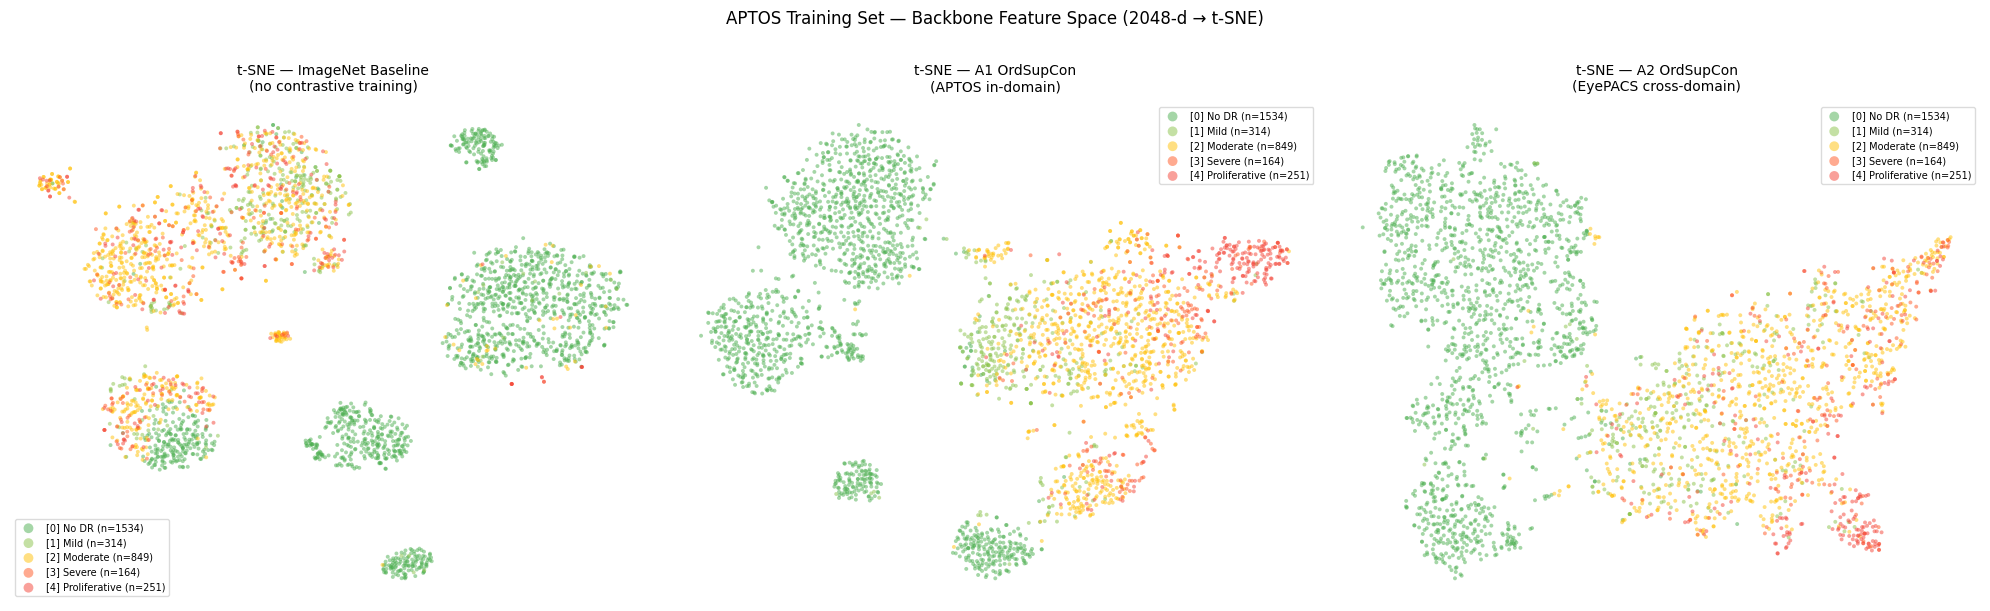

Saved: /workspace/dr-nrt/results/repspace_3way/repspace_tsne_3panel.png


In [10]:
def scatter_2d(
    ax: plt.Axes,
    feats_2d: np.ndarray,
    labels: np.ndarray,
    title: str,
) -> None:
    for cls in range(5):
        mask = labels == cls
        ax.scatter(
            feats_2d[mask, 0], feats_2d[mask, 1],
            c=CLASS_COLORS[cls],
            label=f"[{cls}] {CLASS_NAMES[cls]} (n={mask.sum()})",
            s=8, alpha=0.5, edgecolors="none",
        )
    ax.set_title(title, fontsize=10, pad=8)
    ax.axis("off")
    ax.legend(markerscale=2.5, fontsize=7, loc="best", framealpha=0.7)


fig, axes = plt.subplots(1, 3, figsize=(20, 6))

scatter_2d(axes[0], feats_imgnet_tsne, labels_np,
           "t-SNE — ImageNet Baseline\n(no contrastive training)")
scatter_2d(axes[1], feats_a1_tsne, labels_np,
           "t-SNE — A1 OrdSupCon\n(APTOS in-domain)")
scatter_2d(axes[2], feats_a2_tsne, labels_np,
           "t-SNE — A2 OrdSupCon\n(EyePACS cross-domain)")

fig.suptitle(
    "APTOS Training Set — Backbone Feature Space (2048-d → t-SNE)",
    fontsize=12, y=1.01,
)
plt.tight_layout()
save_path = OUT_DIR / "repspace_tsne_3panel.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {save_path}")

## 8 — Plot: ImageNet vs A1 vs A2 (UMAP, 3 panels)

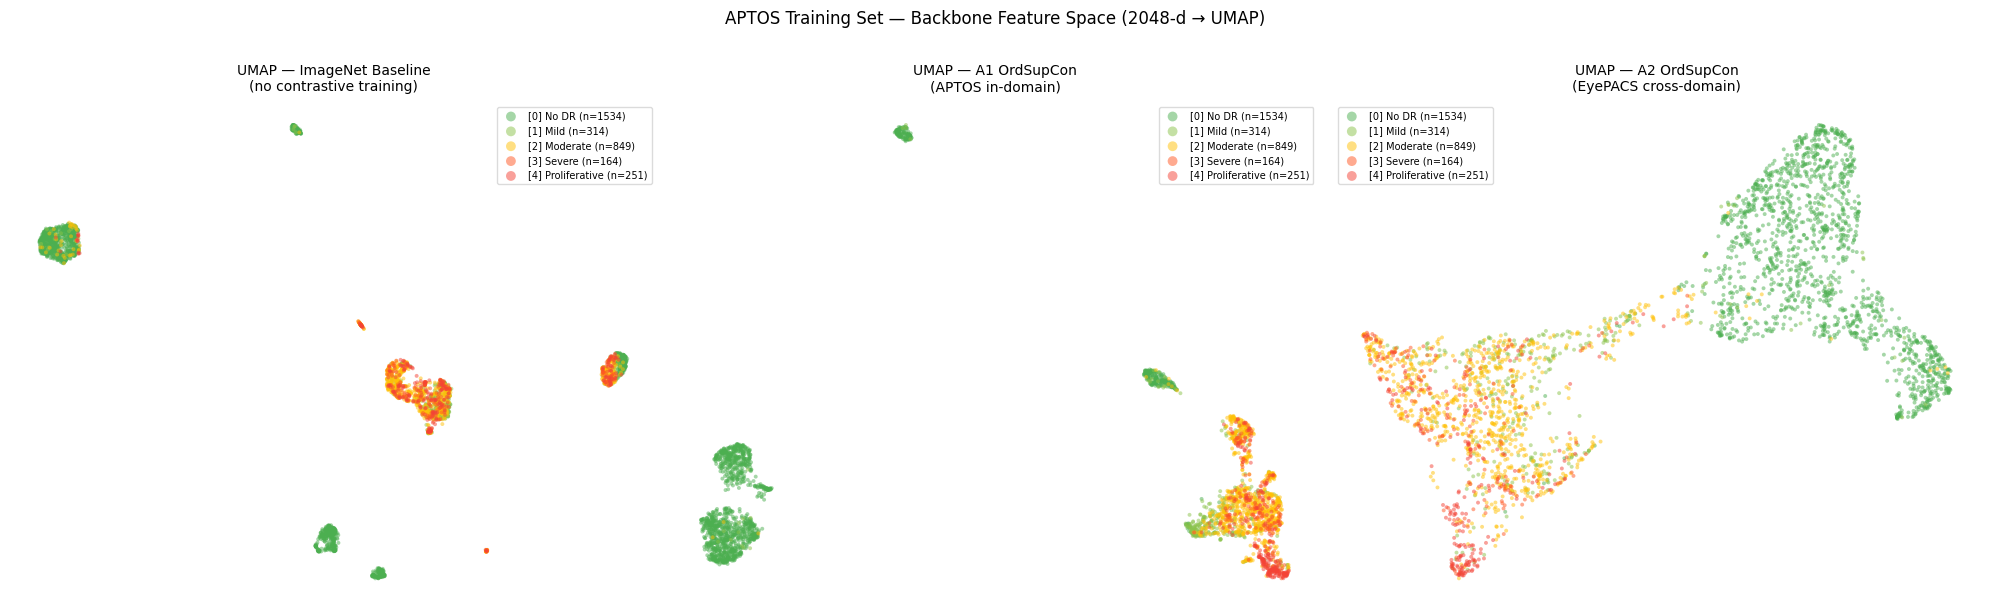

Saved: /workspace/dr-nrt/results/repspace_3way/repspace_umap_3panel.png


In [11]:
if UMAP_AVAILABLE:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    scatter_2d(axes[0], feats_imgnet_umap, labels_np,
               "UMAP — ImageNet Baseline\n(no contrastive training)")
    scatter_2d(axes[1], feats_a1_umap, labels_np,
               "UMAP — A1 OrdSupCon\n(APTOS in-domain)")
    scatter_2d(axes[2], feats_a2_umap, labels_np,
               "UMAP — A2 OrdSupCon\n(EyePACS cross-domain)")

    fig.suptitle(
        "APTOS Training Set — Backbone Feature Space (2048-d → UMAP)",
        fontsize=12, y=1.01,
    )
    plt.tight_layout()
    save_path = OUT_DIR / "repspace_umap_3panel.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")
else:
    print("UMAP not available — skipped.")

## 9 — 2×3 grid: t-SNE row + UMAP row, all three backbones

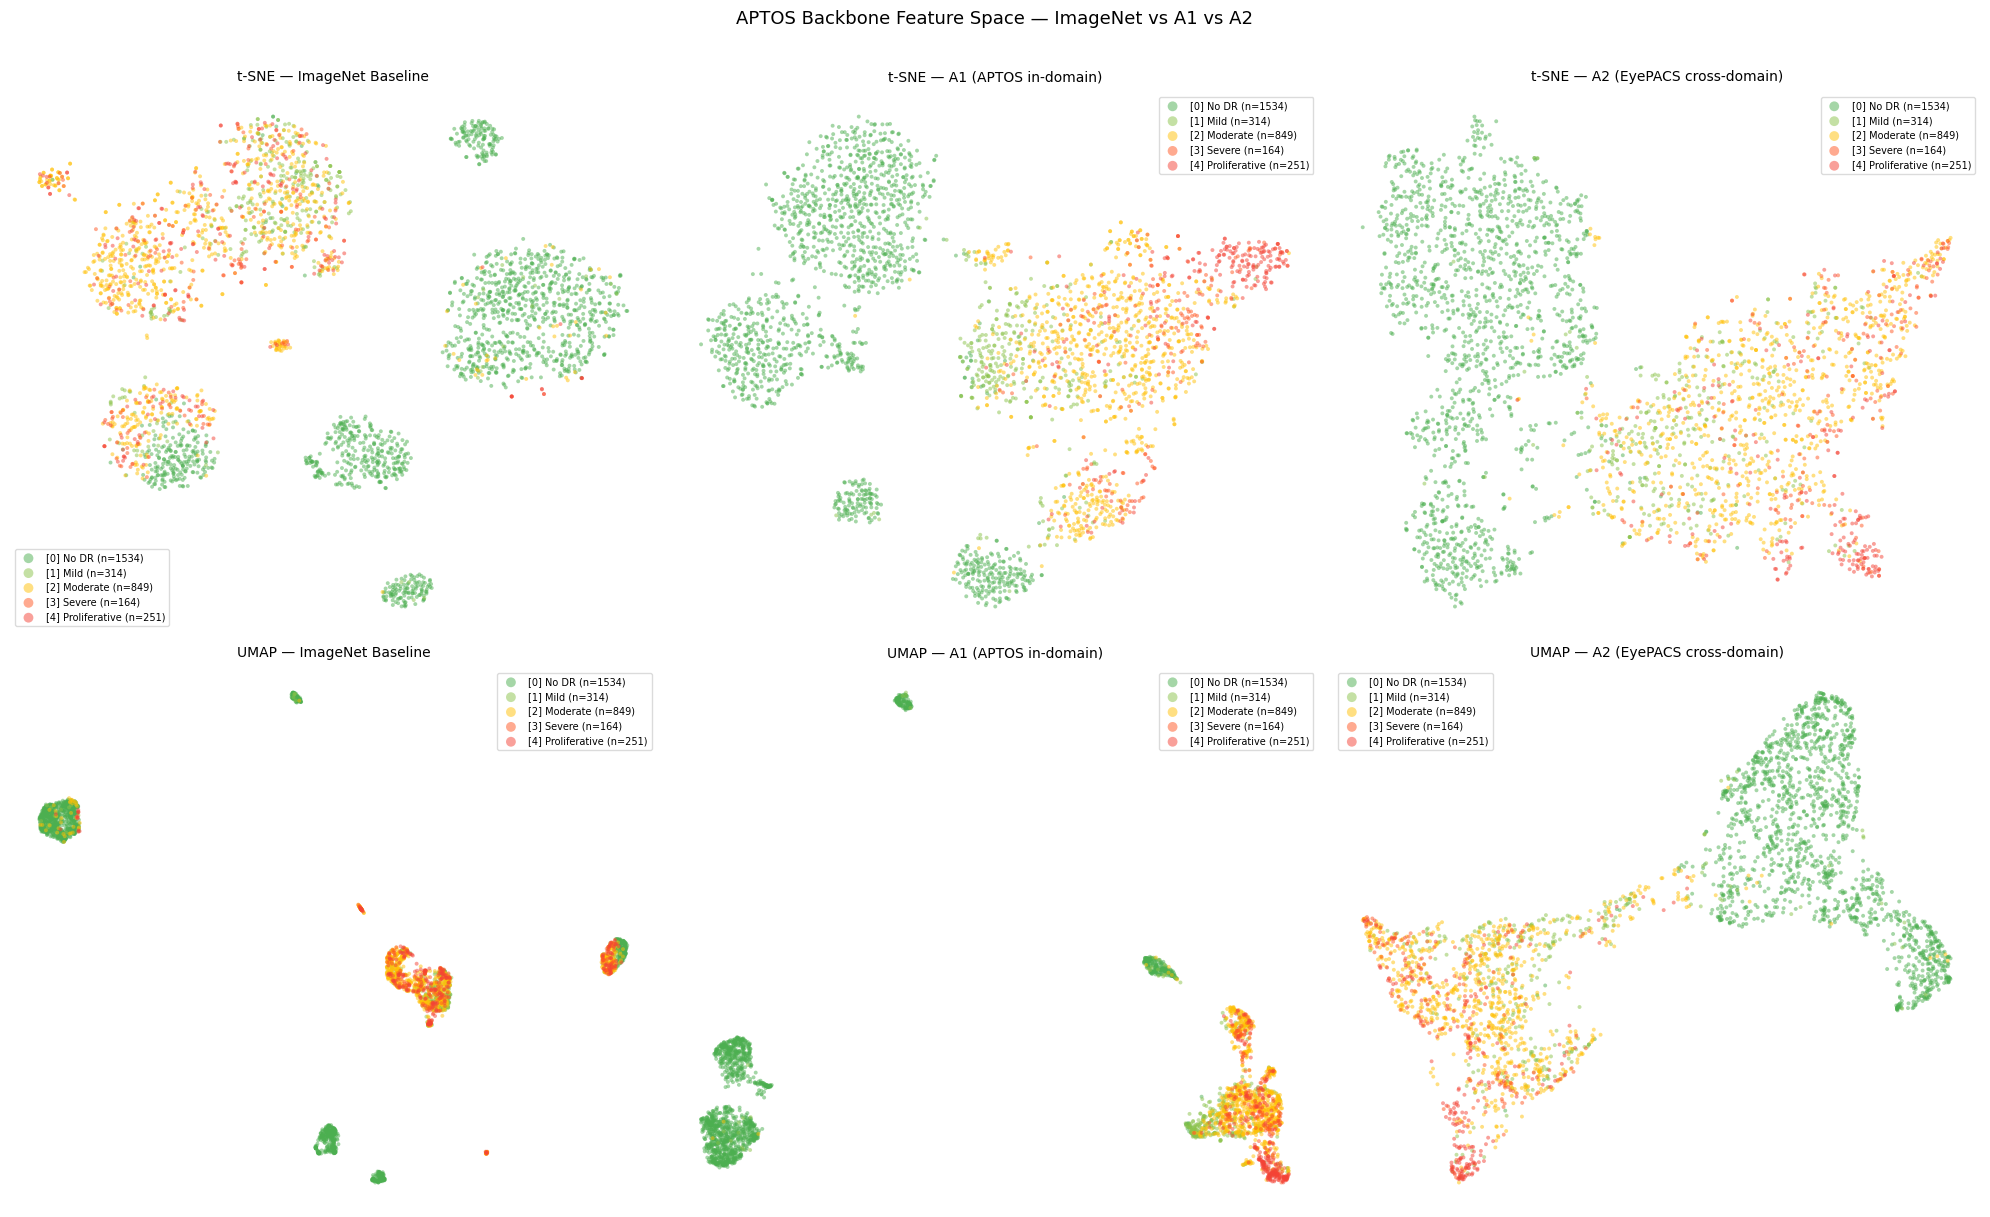

Saved: /workspace/dr-nrt/results/repspace_3way/repspace_grid_6panel.png


In [12]:
if UMAP_AVAILABLE:
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))

    scatter_2d(axes[0][0], feats_imgnet_tsne, labels_np, "t-SNE — ImageNet Baseline")
    scatter_2d(axes[0][1], feats_a1_tsne,     labels_np, "t-SNE — A1 (APTOS in-domain)")
    scatter_2d(axes[0][2], feats_a2_tsne,     labels_np, "t-SNE — A2 (EyePACS cross-domain)")

    scatter_2d(axes[1][0], feats_imgnet_umap, labels_np, "UMAP — ImageNet Baseline")
    scatter_2d(axes[1][1], feats_a1_umap,     labels_np, "UMAP — A1 (APTOS in-domain)")
    scatter_2d(axes[1][2], feats_a2_umap,     labels_np, "UMAP — A2 (EyePACS cross-domain)")

    # Row labels
    for i, row_label in enumerate(["t-SNE", "UMAP"]):
        axes[i][0].set_ylabel(row_label, fontsize=11, labelpad=10)

    fig.suptitle(
        "APTOS Backbone Feature Space — ImageNet vs A1 vs A2",
        fontsize=13, y=1.01,
    )
    plt.tight_layout()
    save_path = OUT_DIR / "repspace_grid_6panel.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")

## 10 — Quantitative: Mean Pairwise L2 Distance Between Class Centroids

Verify that the **ordinal distance structure** is present in each feature space:
- `dist(0, 4)` should be the largest (most different classes).
- `dist(0, 1)` should be the smallest non-zero distance.
- Distances should increase monotonically with `|grade_i − grade_j|`.

We compare class **centroids** in the PCA-50 space for ImageNet, A1, and A2.

In [13]:
import pandas as pd
from itertools import combinations

def pairwise_centroid_distances(
    feats: np.ndarray, labels: np.ndarray, name: str
) -> pd.DataFrame:
    """Compute L2 distance between class centroids in the given feature space."""
    centroids = np.stack([
        feats[labels == cls].mean(axis=0) for cls in range(5)
    ])  # [5, D]

    rows = []
    for i, j in combinations(range(5), 2):
        dist = float(np.linalg.norm(centroids[i] - centroids[j]))
        rows.append({
            "pair": f"{CLASS_NAMES[i][:4]} ↔ {CLASS_NAMES[j][:4]}",
            "|Δgrade|": abs(i - j),
            f"dist ({name})": round(dist, 3),
        })

    df = pd.DataFrame(rows).sort_values("|Δgrade|").reset_index(drop=True)
    return df


df_a1     = pairwise_centroid_distances(feats_a1_pca,     labels_np, "A1")
df_a2     = pairwise_centroid_distances(feats_a2_pca,     labels_np, "A2")
df_imgnet = pairwise_centroid_distances(feats_imgnet_pca, labels_np, "ImageNet")

df_merged = (
    df_imgnet
    .merge(df_a1[["pair", "dist (A1)"]], on="pair")
    .merge(df_a2[["pair", "dist (A2)"]], on="pair")
)

print("Pairwise centroid L2 distances (PCA-50 space)")
print("Both contrastive models should show larger distances for higher |Δgrade|\n")
print(df_merged.to_string(index=False))

csv_path = OUT_DIR / "repspace_centroid_distances.csv"
df_merged.to_csv(csv_path, index=False)
print(f"\nSaved: {csv_path}")

Pairwise centroid L2 distances (PCA-50 space)
Both contrastive models should show larger distances for higher |Δgrade|

       pair  |Δgrade|  dist (ImageNet)  dist (A1)  dist (A2)
No D ↔ Mild         1           11.851     13.358     13.328
Mild ↔ Mode         1            4.781      7.683      5.861
Mode ↔ Seve         1            2.758      6.759      6.375
Seve ↔ Prol         1            2.725      7.351      5.439
Mild ↔ Seve         2            6.526     13.652     11.866
No D ↔ Mode         2           11.629     19.071     18.447
Mode ↔ Prol         2            2.950     11.602      8.386
No D ↔ Seve         3           12.449     24.308     23.763
Mild ↔ Prol         3            5.537     16.370     12.195
No D ↔ Prol         4           12.356     25.648     23.351

Saved: /workspace/dr-nrt/results/repspace_3way/repspace_centroid_distances.csv


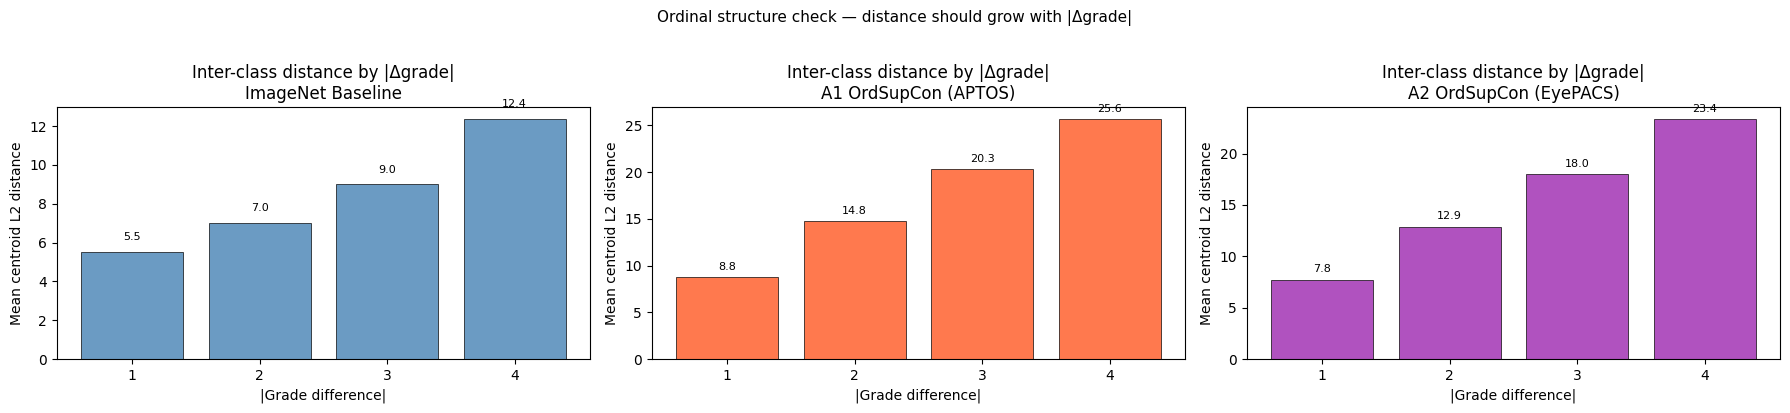

Saved: /workspace/dr-nrt/results/repspace_3way/repspace_ordinal_distances_3panel.png


In [14]:
# Visualise: distance grouped by |Δgrade| — 3 panels.
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=False)

for ax, col, title, color in [
    (axes[0], "dist (ImageNet)", "ImageNet Baseline",        "steelblue"),
    (axes[1], "dist (A1)",       "A1 OrdSupCon (APTOS)",     "#FF5722"),
    (axes[2], "dist (A2)",       "A2 OrdSupCon (EyePACS)",   "#9C27B0"),
]:
    grouped = df_merged.groupby("|Δgrade|")[col].mean()
    bars = ax.bar(grouped.index, grouped.values, color=color, alpha=0.8, edgecolor="black", linewidth=0.6)
    for bar, val in zip(bars, grouped.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{val:.1f}", ha="center", va="bottom", fontsize=8)
    ax.set_xlabel("|Grade difference|")
    ax.set_ylabel("Mean centroid L2 distance")
    ax.set_title(f"Inter-class distance by |Δgrade|\n{title}")
    ax.set_xticks([1, 2, 3, 4])

plt.suptitle("Ordinal structure check — distance should grow with |Δgrade|",
             fontsize=11, y=1.02)
plt.tight_layout()
save_path = OUT_DIR / "repspace_ordinal_distances_3panel.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {save_path}")

## 11 — Summary

| Check | Expected (A1 / A2 OrdSupCon) | Expected (ImageNet) |
|-------|------------------------------|---------------------|
| t-SNE / UMAP ordinal gradient | Grades form a 0 → 1 → 2 → 3 → 4 progression | Mixed / no clear order |
| Grade 0 separated from Grade 4 | Large gap | Smaller gap |
| Distance monotonicity | Grows with \|Δgrade\| | Irregular |
| Grade 3 visible cluster | Somewhat distinct despite small n | Buried in noise |
| A1 vs A2 | A2 (cross-domain EyePACS) may show **similar** ordinal structure to A1 (in-domain APTOS) — supports cross-domain transferability of OrdSupCon. Differences here speak directly to in-domain vs cross-domain pre-training efficacy. | — |

In [15]:
# Monotonicity check for all three backbones.
print("Mean centroid distance by |Δgrade|:\n")
results = {}
for col, label in [
    ("dist (ImageNet)", "ImageNet     "),
    ("dist (A1)",       "A1 (APTOS)   "),
    ("dist (A2)",       "A2 (EyePACS) "),
]:
    g = df_merged.groupby("|Δgrade|")[col].mean()
    diffs = g.diff().dropna()
    monotone = bool((diffs > 0).all())
    results[label.strip()] = monotone
    print(f"  {label}", end="")
    for delta, val in g.items():
        print(f"  |Δ|={delta}: {val:6.2f}", end="")
    print(f"   →  {'✅ monotone' if monotone else '⚠️  not monotone'}")

print("\nSummary:")
for label, ok in results.items():
    msg = "encoded ordinal grade structure" if ok else "ordinal structure incomplete"
    print(f"  {label:<14} : {msg}")

Mean centroid distance by |Δgrade|:

  ImageNet       |Δ|=1:   5.53  |Δ|=2:   7.04  |Δ|=3:   8.99  |Δ|=4:  12.36   →  ✅ monotone
  A1 (APTOS)     |Δ|=1:   8.79  |Δ|=2:  14.78  |Δ|=3:  20.34  |Δ|=4:  25.65   →  ✅ monotone
  A2 (EyePACS)   |Δ|=1:   7.75  |Δ|=2:  12.90  |Δ|=3:  17.98  |Δ|=4:  23.35   →  ✅ monotone

Summary:
  ImageNet       : encoded ordinal grade structure
  A1 (APTOS)     : encoded ordinal grade structure
  A2 (EyePACS)   : encoded ordinal grade structure
